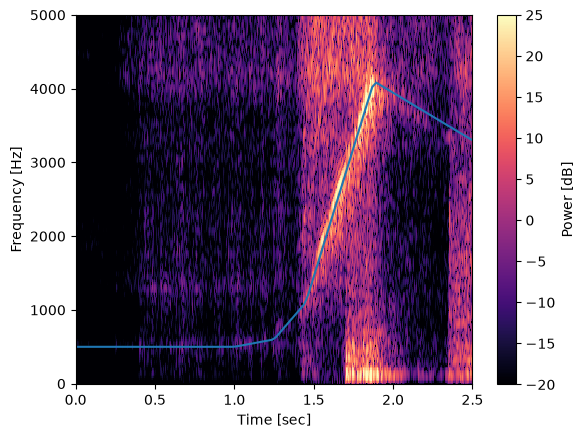

In [28]:
from scipy.io import wavfile
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from scipy import interpolate



WAV, BLADES = "20250709-002_2160p60.wav", 35
fs, x = wavfile.read(WAV)
f, t, Sxx = spectrogram(x = x, fs = fs, nfft=2000, nperseg=400, noverlap=300)

n_zero = 161
fps = 60

t_zero = 161 * 1/60

plt.pcolormesh(t - t_zero, f, 10 * np.log10(Sxx), cmap="magma",vmin=-20, vmax=25)
plt.colorbar(label="Power [dB]")
plt.ylabel("Frequency [Hz]")
plt.xlabel("Time [sec]")
plt.xlim([0, 2.5])
plt.ylim(top=5000)

t_speed = [0, 1, 1.25, 1.45, 1.88, 2.5]
f_speed = [500, 500, 600, 1100, 4100, 3300]

# We can now do a polyfit
func = interpolate.interp1d(t_speed, f_speed)

t_array = np.linspace(0, 2.5, 100)
plt.plot(t_array, func(t_array))

import pandas as pd
pd.DataFrame({"time": t_array, "rpm": func(t_array)}).to_csv("rpm.csv", index=False)